<a href="https://colab.research.google.com/github/YuriiKlim/Amazinum_Camp/blob/Homeworks/Lesson4_HW_Car_Insurance_Claim.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [34]:
CIC_df = pd.read_csv("https://raw.githubusercontent.com/OleksiyTsebriy/Camp_2025/refs/heads/main/lesson_4_visualization/data/Car_Insurance_Claim.csv")
CIC_df

,Unnamed: 0,ID,AGE,GENDER,RACE,DRIVING_EXPERIENCE,EDUCATION,INCOME,CREDIT_SCORE,VEHICLE_OWNERSHIP,VEHICLE_YEAR,MARRIED,CHILDREN,POSTAL_CODE,ANNUAL_MILEAGE,VEHICLE_TYPE,SPEEDING_VIOLATIONS,DUIS,PAST_ACCIDENTS,OUTCOME
0,0,569520,65+,female,majority,0-9y,high school,upper class,0.629027313918201,1.0,after 2015,0.0,1.0,10238,12000.0,sedan,0,0,0,0.0
1,1,750365,16-25,male,majority,0-9y,none,poverty,0.3577571170184627,0.0,before 2015,0.0,0.0,10238,16000.0,sedan,0,0,0,1.0
2,2,199901,16-25,female,majority,0-9y,high school,working class,0.4931457852181982,1.0,before 2015,0.0,0.0,10238,11000.0,sedan,0,0,0,0.0
3,3,478866,16-25,male,majority,0-9y,university,working class,0.2060128507324556,1.0,before 2015,0.0,none,32765,11000.0,sedan,0,0,0,0.0
4,4,731664,26-39,male,majority,10-19y,none,working class,0.3883658881572184,1.0,before 2015,0.0,0.0,32765.0,12000.0,sedan,2,0,1,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9995,323164,26-39,female,majority,10-19y,university,upper class,0.5827870696562382,1.0,before 2015,0.0,0.0,10238,16000.0,sedan,0,0,1,0.0
9996,9996,910346,26-39,female,majority,10-19y,none,middle class,0.5222314755016938,1.0,after 2015,0.0,1.0,32765,NaN,sedan,1,0,0,0.0
9997,9997,468409,26-39,male,majority,0-9y,high school,middle class,0.4709402314479679,1.0,before 2015,0.0,1.0,10238,14000.0,sedan,0,0,0,0.0
9998,9998,903459,26-39,female,majority,10-19y,high school,poverty,0.3641847847297929,0.0,before 2015,0.0,1.0,10238,13000.0,sedan,2,0,1,1.0


* ID – a unique client identifier.
* AGE – age (categorical, for example, “16-25”, “65+”).
* GENDER – gender of the client (male, female).
* RACE – race (majority, minority).
* DRIVING_EXPERIENCE – driving experience (0-9y, 10-19y, etc.).
* EDUCATION – level of education (high school, university, none).
* INCOME – income level (poverty, working class, upper class).
* CREDIT_SCORE – credit rating (numerical indicator).
* VEHICLE_OWNERSHIP – whether the customer owns a car (0 - no, 1 - yes).
* VEHICLE_YEAR – year of manufacture of the car (before 2015, after 2015).
* MARRIED – or married (0 - no, 1 - yes).
* CHILDREN – number of children.
* POSTAL_CODE – postal code.
* ANNUAL_MILEAGE – annual mileage of the car.
* VEHICLE_TYPE – type of car (sedan, sports car, etc.).
* SPEEDING_VIOLATIONS – number of speeding violations.
* DUIS – the number of cases of driving while intoxicated.
* PAST_ACCIDENTS – number of past accidents.
* OUTCOME – result (availability of insurance payment: 0 - no, 1 - yes).

In [35]:
CIC_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Unnamed: 0           10000 non-null  int64 
 1   ID                   10000 non-null  int64 
 2   AGE                  9950 non-null   object
 3   GENDER               9950 non-null   object
 4   RACE                 9951 non-null   object
 5   DRIVING_EXPERIENCE   9950 non-null   object
 6   EDUCATION            9951 non-null   object
 7   INCOME               10000 non-null  object
 8   CREDIT_SCORE         8978 non-null   object
 9   VEHICLE_OWNERSHIP    9950 non-null   object
 10  VEHICLE_YEAR         9950 non-null   object
 11  MARRIED              9952 non-null   object
 12  CHILDREN             9950 non-null   object
 13  POSTAL_CODE          9950 non-null   object
 14  ANNUAL_MILEAGE       9000 non-null   object
 15  VEHICLE_TYPE         9951 non-null   object
 16  SPEED

In [36]:
CIC_df = CIC_df.drop(columns=["Unnamed: 0", "ID", "POSTAL_CODE"])

In [37]:
# Create a table of unique values for the specified columns
unique_values = {col: CIC_df[col].unique() for col in [
    "AGE", "GENDER", "RACE", "DRIVING_EXPERIENCE", "EDUCATION", "INCOME",
    "VEHICLE_OWNERSHIP", "VEHICLE_YEAR", "MARRIED", "CHILDREN", "VEHICLE_TYPE",
    "SPEEDING_VIOLATIONS", "DUIS", "PAST_ACCIDENTS", "OUTCOME"
]}

# Convert to DataFrame for easy display
df_unique_values = pd.DataFrame(dict([(k, [', '.join(map(str, v))]) for k, v in unique_values.items()]))

df_unique_values

,AGE,GENDER,RACE,DRIVING_EXPERIENCE,EDUCATION,INCOME,VEHICLE_OWNERSHIP,VEHICLE_YEAR,MARRIED,CHILDREN,VEHICLE_TYPE,SPEEDING_VIOLATIONS,DUIS,PAST_ACCIDENTS,OUTCOME
0,"65+, 16-25, 26-39, 40-64, none, nan","female, male, none, nan","majority, minority, nan, none","0-9y, 10-19y, 20-29y, 30y+, nan, none","high school, none, university, nan","upper class, poverty, working class, middle class","1.0, 0.0, none, nan","after 2015, before 2015, nan, none","0.0, 1.0, nan, none","1.0, 0.0, none, nan","sedan, sports car, none, nan","0, 2, 3, 7, 6, 4, 10, 13, 1, 5, 9, 8, 12, nan,...","0, 2, 1, nan, none, 3, 4, 5, 6","0, 1, 3, 7, 2, 5, 4, nan, 6, 8, 10, none, 11, ...","0.0, 1.0, none, nan"


In [38]:
columns_to_replace = [
    "DRIVING_EXPERIENCE", "VEHICLE_OWNERSHIP", "MARRIED", "CHILDREN",
    "SPEEDING_VIOLATIONS", "DUIS", "PAST_ACCIDENTS", "OUTCOME", "ANNUAL_MILEAGE"
]

for col in columns_to_replace:
    CIC_df[col] = CIC_df[col].replace("none", 0)

In [39]:
columns_to_replace_unknown = ["AGE", "GENDER", "RACE", "VEHICLE_YEAR", "VEHICLE_TYPE"]

for col in columns_to_replace_unknown:
    CIC_df[col] = CIC_df[col].replace("none", "unknown")

In [40]:
# Convert numeric values to appropriate formats
CIC_df["MARRIED"] = pd.to_numeric(CIC_df["MARRIED"]).astype(float)
CIC_df["VEHICLE_OWNERSHIP"] = pd.to_numeric(CIC_df["VEHICLE_OWNERSHIP"]).astype(float)
CIC_df["SPEEDING_VIOLATIONS"] = pd.to_numeric(CIC_df["SPEEDING_VIOLATIONS"]).astype(float)
CIC_df["DUIS"] = pd.to_numeric(CIC_df["DUIS"]).astype(float)
CIC_df["PAST_ACCIDENTS"] = pd.to_numeric(CIC_df["PAST_ACCIDENTS"]).astype(float)
CIC_df["OUTCOME"] = pd.to_numeric(CIC_df["OUTCOME"]).astype(float)
CIC_df["CHILDREN"] = pd.to_numeric(CIC_df["CHILDREN"]).astype(float)
CIC_df["ANNUAL_MILEAGE"] = pd.to_numeric(CIC_df["ANNUAL_MILEAGE"]).astype(float)

In [41]:
CIC_df["CREDIT_SCORE"] = CIC_df["CREDIT_SCORE"].replace("none", 0)
CIC_df["CREDIT_SCORE"] = pd.to_numeric(CIC_df["CREDIT_SCORE"]).astype(float)

In [42]:
CIC_df.describe()

,CREDIT_SCORE,VEHICLE_OWNERSHIP,MARRIED,CHILDREN,ANNUAL_MILEAGE,SPEEDING_VIOLATIONS,DUIS,PAST_ACCIDENTS,OUTCOME
count,8978.000000,9950.000000,9952.000000,9950.000000,9000.000000,9950.000000,9950.000000,9950.000000,9950.000000
mean,0.512943,0.694171,0.495378,0.684925,11633.444444,1.474472,0.237688,1.052060,0.312060
std,0.142454,0.460781,0.500004,0.464569,2944.003328,2.236967,0.554123,1.651245,0.463358
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.415385,0.000000,0.000000,0.000000,10000.000000,0.000000,0.000000,0.000000,0.000000
50%,0.523770,1.000000,0.000000,1.000000,12000.000000,0.000000,0.000000,0.000000,0.000000
75%,0.617757,1.000000,1.000000,1.000000,14000.000000,2.000000,0.000000,2.000000,1.000000
max,0.960819,1.000000,1.000000,1.000000,22000.000000,22.000000,6.000000,15.000000,1.000000


In [43]:
CIC_df = CIC_df.dropna(subset=["OUTCOME"])
CIC_df

,AGE,GENDER,RACE,DRIVING_EXPERIENCE,EDUCATION,INCOME,CREDIT_SCORE,VEHICLE_OWNERSHIP,VEHICLE_YEAR,MARRIED,CHILDREN,ANNUAL_MILEAGE,VEHICLE_TYPE,SPEEDING_VIOLATIONS,DUIS,PAST_ACCIDENTS,OUTCOME
0,65+,female,majority,0-9y,high school,upper class,0.629027,1.0,after 2015,0.0,1.0,12000.0,sedan,0.0,0.0,0.0,0.0
1,16-25,male,majority,0-9y,none,poverty,0.357757,0.0,before 2015,0.0,0.0,16000.0,sedan,0.0,0.0,0.0,1.0
2,16-25,female,majority,0-9y,high school,working class,0.493146,1.0,before 2015,0.0,0.0,11000.0,sedan,0.0,0.0,0.0,0.0
3,16-25,male,majority,0-9y,university,working class,0.206013,1.0,before 2015,0.0,0.0,11000.0,sedan,0.0,0.0,0.0,0.0
4,26-39,male,majority,10-19y,none,working class,0.388366,1.0,before 2015,0.0,0.0,12000.0,sedan,2.0,0.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,26-39,female,majority,10-19y,university,upper class,0.582787,1.0,before 2015,0.0,0.0,16000.0,sedan,0.0,0.0,1.0,0.0
9996,26-39,female,majority,10-19y,none,middle class,0.522231,1.0,after 2015,0.0,1.0,NaN,sedan,1.0,0.0,0.0,0.0
9997,26-39,male,majority,0-9y,high school,middle class,0.470940,1.0,before 2015,0.0,1.0,14000.0,sedan,0.0,0.0,0.0,0.0
9998,26-39,female,majority,10-19y,high school,poverty,0.364185,0.0,before 2015,0.0,1.0,13000.0,sedan,2.0,0.0,1.0,1.0


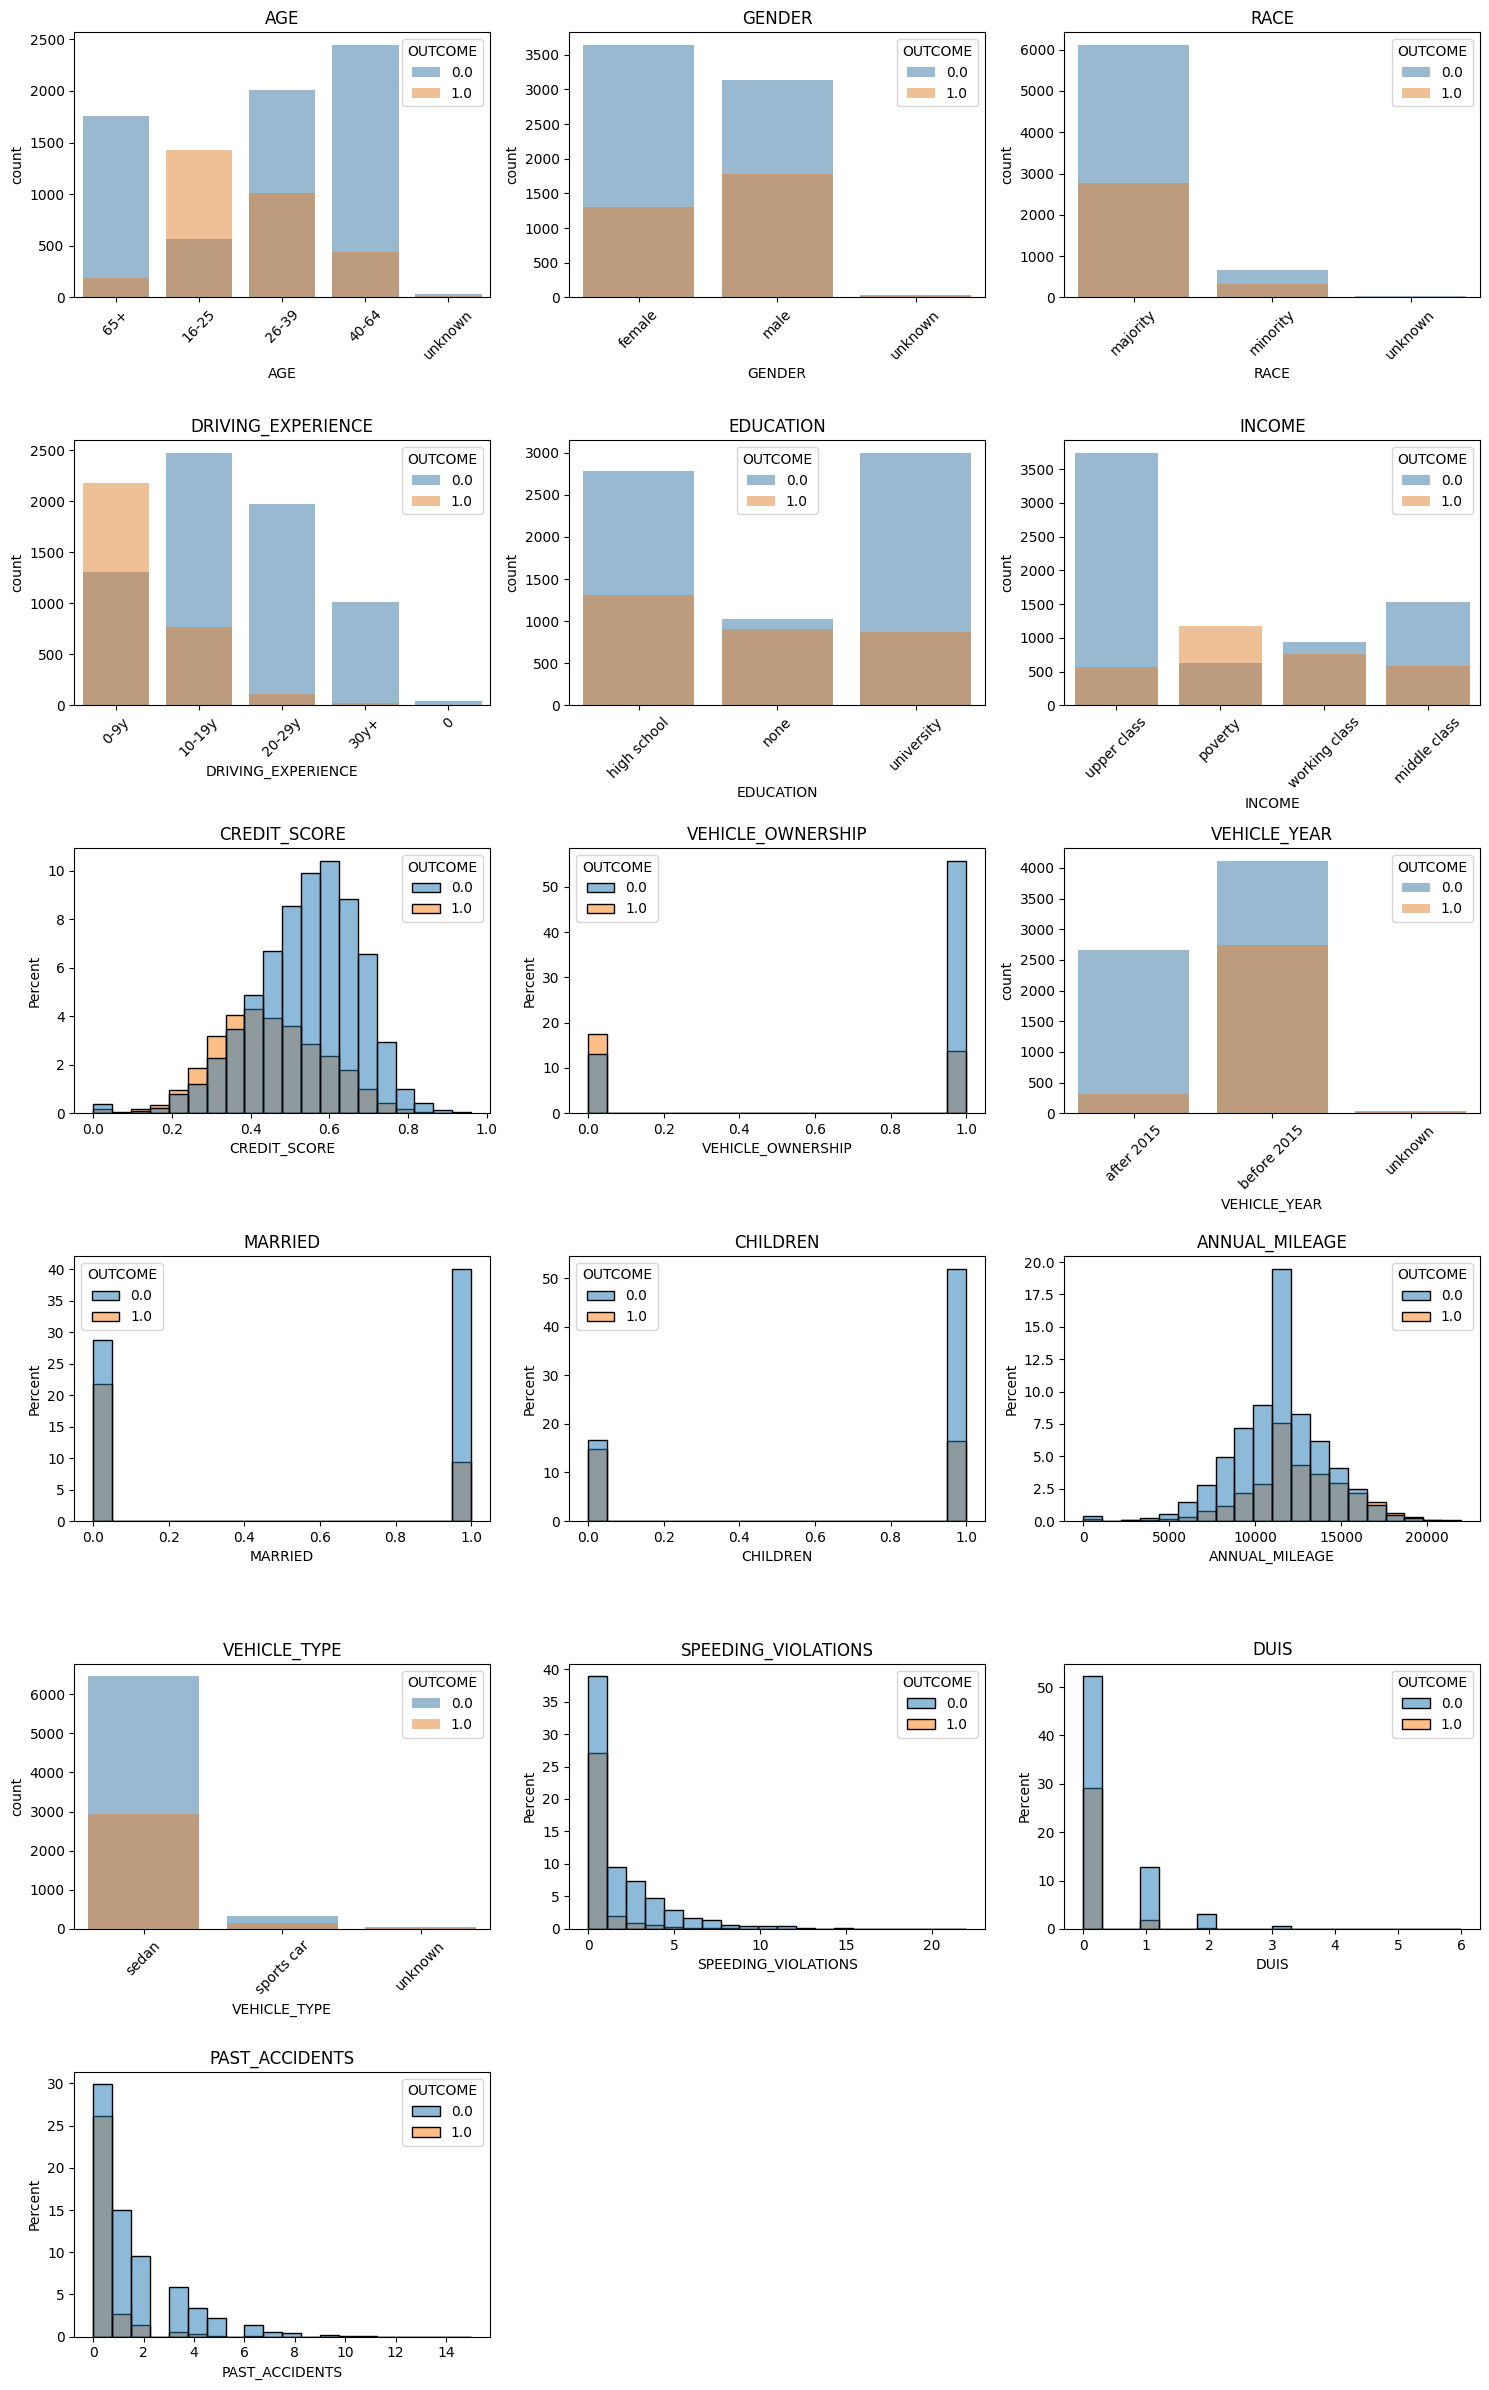

In [44]:
# Get a list of columns to build (except OUTCOME)
columns_to_plot = [col for col in CIC_df.columns if col != "OUTCOME"]

# Set up a graph grid
ncols = 3
nrows = math.ceil(len(columns_to_plot) / ncols)
plt.figure(figsize=(5 * ncols, 4 * nrows))

for i, col in enumerate(columns_to_plot, start=1):
    ax = plt.subplot(nrows, ncols, i)

    if pd.api.types.is_numeric_dtype(CIC_df[col]):
        # Building a histogram for numeric columns with an overlay by OUTCOME
        sns.histplot(
            data=CIC_df,
            x=col,
            bins=20,
            kde=False,
            hue="OUTCOME",
            stat="percent",
            multiple="layer",
            alpha=0.5,
            ax=ax
        )
        # Getting legendary objects and labels
        handles, labels = ax.get_legend_handles_labels()
        if handles:
            ax.legend(handles, labels, title="OUTCOME")
    else:
        # Building a chart for categorical columns with an overlay by OUTCOME
        sns.countplot(data=CIC_df, x=col, hue="OUTCOME", dodge=False, ax=ax)
        for patch in ax.patches:
            patch.set_alpha(0.5)
        handles, labels = ax.get_legend_handles_labels()
        if handles:
            ax.legend(handles, labels, title="OUTCOME")
        plt.xticks(rotation=45)

    ax.set_title(col)
    plt.tight_layout()

plt.show()

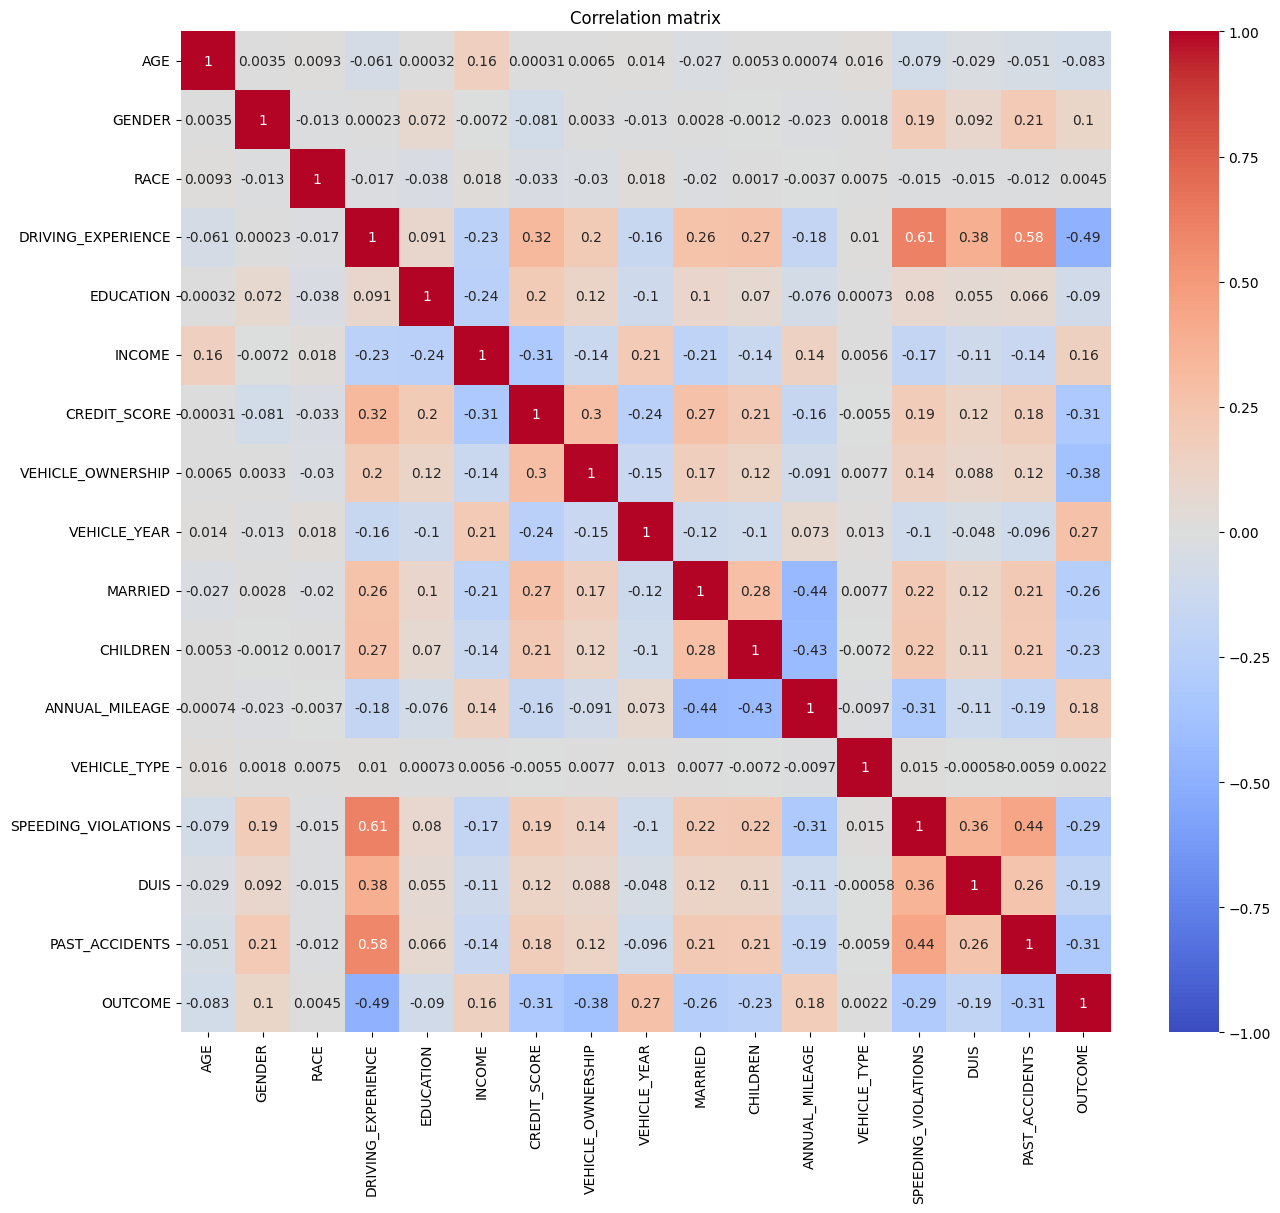

In [45]:
df_encoded = CIC_df.copy()

plt.figure(figsize=(15, 13))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation matrix")
plt.show()

# Conclusion
As we can see, there is no clear correlation between each of the various features and claims.

But according to the histograms, the ratio of paid claims to unpaid claims is higher for young drivers with little driving experience and low income. There is also a noticeable shift in the number of payments towards people with lower credit ratings.

Therefore, we can conclude that, according to this dataset, the insurance claims system is more loyal to people who need these payments more.